In [1]:
# Nếu Kaggle chưa có timm/thop thì cài thêm
!pip install -q timm thop

import os
import time
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

import timm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from thop import profile

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 85.9 MB/s eta 0:00:00:00:01:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which 

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Đường dẫn dataset
DATA_ROOT = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset"

TRAIN_DIR = os.path.join(DATA_ROOT, "Training")
TEST_DIR = os.path.join(DATA_ROOT, "Testing")

print("Train dir exists:", os.path.exists(TRAIN_DIR))
print("Test dir exists:", os.path.exists(TEST_DIR))

# Hyperparameters
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 4

EPOCHS = 30
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

VAL_RATIO = 0.15
PATIENCE = 5

MODEL_NAME = "vit_tiny_patch16_224"
SAVE_PATH = "/kaggle/working/vit_tiny_brain_tumor_best.pth"

Device: cuda
Train dir exists: True
Test dir exists: True


In [3]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [4]:
full_train_dataset = ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform
)

test_dataset = ImageFolder(
    root=TEST_DIR,
    transform=test_transform
)

class_names = full_train_dataset.classes
print("Classes:", class_names)
print("Class to index:", full_train_dataset.class_to_idx)

train_size = int((1 - VAL_RATIO) * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Validation không nên dùng augmentation
val_dataset.dataset = ImageFolder(
    root=TRAIN_DIR,
    transform=test_transform
)

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Class to index: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Train size: 4760
Val size: 840
Test size: 1600


In [7]:
# Dataloader
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [8]:
def count_images_per_class(dataset_path):
    counts = {}
    for class_name in sorted(os.listdir(dataset_path)):
        class_path = os.path.join(dataset_path, class_name)
        if os.path.isdir(class_path):
            counts[class_name] = len(os.listdir(class_path))
    return counts

train_counts = count_images_per_class(TRAIN_DIR)
test_counts = count_images_per_class(TEST_DIR)

print("Training set:")
print(train_counts)

print("\nTesting set:")
print(test_counts)

Training set:
{'glioma': 1400, 'meningioma': 1400, 'notumor': 1400, 'pituitary': 1400}

Testing set:
{'glioma': 400, 'meningioma': 400, 'notumor': 400, 'pituitary': 400}


In [9]:
model = timm.create_model(
    MODEL_NAME,
    pretrained=False,   
    num_classes=NUM_CLASSES
)

model = model.to(device)

print(model)

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)


In [10]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

In [11]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        preds = torch.argmax(outputs, dim=1)

        running_loss += loss.item() * images.size(0)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)

    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    epoch_recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    return epoch_loss, epoch_acc, epoch_precision, epoch_recall, epoch_f1

In [12]:
def evaluate_model(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            preds = torch.argmax(outputs, dim=1)

            running_loss += loss.item() * images.size(0)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)

    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    epoch_recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    return epoch_loss, epoch_acc, epoch_precision, epoch_recall, epoch_f1, all_labels, all_preds

In [13]:
best_val_f1 = -1.0
best_epoch = 0
epochs_without_improvement = 0

history = {
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "train_precision_macro": [],
    "train_recall_macro": [],
    "train_f1_macro": [],
    "val_loss": [],
    "val_acc": [],
    "val_precision_macro": [],
    "val_recall_macro": [],
    "val_f1_macro": [],
}

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch [{epoch}/{EPOCHS}]")

    train_loss, train_acc, train_precision, train_recall, train_f1 = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc, val_precision, val_recall, val_f1, _, _ = evaluate_model(
        model, val_loader, criterion, device
    )

    scheduler.step(val_f1)

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_precision_macro"].append(train_precision)
    history["train_recall_macro"].append(train_recall)
    history["train_f1_macro"].append(train_f1)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_precision_macro"].append(val_precision)
    history["val_recall_macro"].append(val_recall)
    history["val_f1_macro"].append(val_f1)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Acc: {train_acc:.4f} | Precision: {train_precision:.4f} | Recall: {train_recall:.4f} | F1: {train_f1:.4f}")

    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val Acc: {val_acc:.4f} | Precision: {val_precision:.4f} | Recall: {val_recall:.4f} | F1: {val_f1:.4f}")

    # Autosave sau epoch đầu tiên, sau đó nếu tốt hơn thì lưu đè
    if epoch == 1 or val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch
        epochs_without_improvement = 0

        torch.save({
            "epoch": epoch,
            "model_name": MODEL_NAME,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val_f1": best_val_f1,
            "class_names": class_names,
            "img_size": IMG_SIZE
        }, SAVE_PATH)

        print(f"Saved best model to: {SAVE_PATH}")
    else:
        epochs_without_improvement += 1
        print(f"No improvement for {epochs_without_improvement} epoch(s).")

    if epochs_without_improvement >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.")
        print(f"Best epoch: {best_epoch}")
        print(f"Best validation Macro F1: {best_val_f1:.4f}")
        break

print("\nTraining finished.")
print("Best epoch:", best_epoch)
print("Best validation Macro F1:", best_val_f1)


Epoch [1/30]
Train Loss: 1.1247
Train Acc: 0.5074 | Precision: 0.5006 | Recall: 0.5073 | F1: 0.4999
Val Loss: 0.9370
Val Acc: 0.6274 | Precision: 0.6288 | Recall: 0.6284 | F1: 0.6105
Saved best model to: /kaggle/working/vit_tiny_brain_tumor_best.pth

Epoch [2/30]
Train Loss: 0.9277
Train Acc: 0.6359 | Precision: 0.6387 | Recall: 0.6356 | F1: 0.6339
Val Loss: 0.9221
Val Acc: 0.6512 | Precision: 0.6935 | Recall: 0.6586 | F1: 0.6533
Saved best model to: /kaggle/working/vit_tiny_brain_tumor_best.pth

Epoch [3/30]
Train Loss: 0.8610
Train Acc: 0.6727 | Precision: 0.6746 | Recall: 0.6723 | F1: 0.6724
Val Loss: 0.7951
Val Acc: 0.6988 | Precision: 0.7101 | Recall: 0.7036 | F1: 0.6999
Saved best model to: /kaggle/working/vit_tiny_brain_tumor_best.pth

Epoch [4/30]
Train Loss: 0.8045
Train Acc: 0.6916 | Precision: 0.6930 | Recall: 0.6912 | F1: 0.6915
Val Loss: 0.8158
Val Acc: 0.6929 | Precision: 0.7339 | Recall: 0.6999 | F1: 0.6922
No improvement for 1 epoch(s).

Epoch [5/30]
Train Loss: 0.7450

In [14]:
history_df = pd.DataFrame(history)
history_csv_path = "/kaggle/working/vit_tiny_training_history.csv"
history_df.to_csv(history_csv_path, index=False)

history_df

,epoch,train_loss,train_acc,train_precision_macro,train_recall_macro,train_f1_macro,val_loss,val_acc,val_precision_macro,val_recall_macro,val_f1_macro
0,1,1.124692,0.507353,0.500568,0.507260,0.499884,0.937017,0.627381,0.628751,0.628400,0.610549
1,2,0.927665,0.635924,0.638735,0.635585,0.633923,0.922063,0.651190,0.693541,0.658638,0.653269
2,3,0.861027,0.672689,0.674612,0.672268,0.672427,0.795145,0.698810,0.710145,0.703568,0.699921
3,4,0.804476,0.691597,0.693000,0.691234,0.691462,0.815841,0.692857,0.733864,0.699903,0.692241
4,5,0.744970,0.717227,0.718025,0.716775,0.716896,0.691896,0.725000,0.742694,0.730751,0.726759
5,6,0.692690,0.730672,0.730851,0.730155,0.729407,0.676636,0.730952,0.734385,0.732329,0.731693
6,7,0.648757,0.748319,0.747708,0.747808,0.747156,0.660217,0.732143,0.743119,0.736058,0.721980
7,8,0.604024,0.761975,0.761438,0.761446,0.760365,0.773550,0.698810,0.751358,0.706390,0.682183
8,9,0.561215,0.778361,0.776881,0.777882,0.776596,0.570954,0.790476,0.789254,0.793770,0.787931
9,10,0.526016,0.796008,0.794684,0.795490,0.794400,0.507997,0.817857,0.827031,0.822485,0.818575


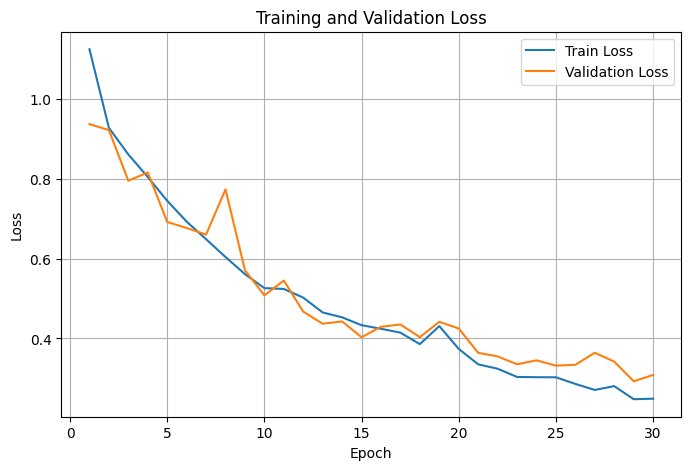

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

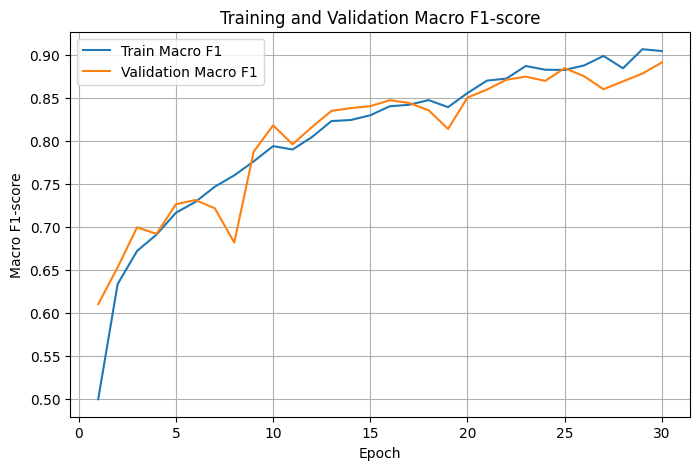

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_f1_macro"], label="Train Macro F1")
plt.plot(history_df["epoch"], history_df["val_f1_macro"], label="Validation Macro F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1-score")
plt.title("Training and Validation Macro F1-score")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
checkpoint = torch.load(SAVE_PATH, map_location=device)

best_model = timm.create_model(
    checkpoint["model_name"],
    pretrained=False,
    num_classes=NUM_CLASSES
)

best_model.load_state_dict(checkpoint["model_state_dict"])
best_model = best_model.to(device)
best_model.eval()

print("Loaded best model from:", SAVE_PATH)
print("Best epoch:", checkpoint["epoch"])
print("Best validation Macro F1:", checkpoint["best_val_f1"])

Loaded best model from: /kaggle/working/vit_tiny_brain_tumor_best.pth
Best epoch: 30
Best validation Macro F1: 0.8917268331014726


In [18]:
test_loss, test_acc, test_precision, test_recall, test_f1, y_true, y_pred = evaluate_model(
    best_model,
    test_loader,
    criterion,
    device
)

print("Test Results")
print("-" * 40)
print(f"Test Loss: {test_loss:.4f}")
print(f"Accuracy: {test_acc:.4f}")
print(f"Macro Precision: {test_precision:.4f}")
print(f"Macro Recall: {test_recall:.4f}")
print(f"Macro F1-score: {test_f1:.4f}")

Test Results
----------------------------------------
Test Loss: 0.5551
Accuracy: 0.8581
Macro Precision: 0.8652
Macro Recall: 0.8581
Macro F1-score: 0.8519


In [19]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

      glioma     0.9328    0.6250    0.7485       400
  meningioma     0.7859    0.8350    0.8097       400
     notumor     0.9014    0.9825    0.9402       400
   pituitary     0.8408    0.9900    0.9093       400

    accuracy                         0.8581      1600
   macro avg     0.8652    0.8581    0.8519      1600
weighted avg     0.8652    0.8581    0.8519      1600



<Figure size 800x800 with 0 Axes>

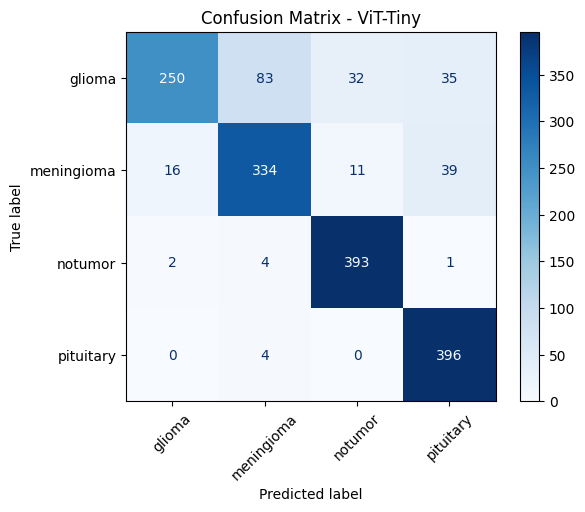

In [20]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

plt.figure(figsize=(8, 8))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - ViT-Tiny")
plt.xticks(rotation=45)
plt.show()

In [21]:
results = {
    "model": [MODEL_NAME],
    "test_loss": [test_loss],
    "accuracy": [test_acc],
    "macro_precision": [test_precision],
    "macro_recall": [test_recall],
    "macro_f1": [test_f1],
    "best_epoch": [checkpoint["epoch"]],
    "best_val_f1": [checkpoint["best_val_f1"]]
}

results_df = pd.DataFrame(results)

results_csv_path = "/kaggle/working/vit_tiny_test_results.csv"
results_df.to_csv(results_csv_path, index=False)

results_df

,model,test_loss,accuracy,macro_precision,macro_recall,macro_f1,best_epoch,best_val_f1
0,vit_tiny_patch16_224,0.555105,0.858125,0.865215,0.858125,0.851923,30,0.891727


In [22]:
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params

total_params, trainable_params = count_parameters(best_model)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Total parameters: {total_params / 1e6:.3f} M")

Total parameters: 5,525,188
Trainable parameters: 5,525,188
Total parameters: 5.525 M


In [23]:
model_size_bytes = os.path.getsize(SAVE_PATH)
model_size_mb = model_size_bytes / (1024 * 1024)

print(f"Model file size: {model_size_mb:.2f} MB")

Model file size: 63.42 MB


In [24]:
best_model.eval()

dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)

macs, params = profile(
    best_model,
    inputs=(dummy_input,),
    verbose=False
)

gmacs = macs / 1e9
gflops = (2 * macs) / 1e9
params_m = params / 1e6

print(f"MACs: {gmacs:.3f} GMACs")
print(f"Approx FLOPs: {gflops:.3f} GFLOPs")
print(f"Parameters from THOP: {params_m:.3f} M")

MACs: 1.075 GMACs
Approx FLOPs: 2.149 GFLOPs
Parameters from THOP: 5.478 M


In [25]:
def measure_latency(model, device, input_size=(1, 3, 224, 224), warmup=50, runs=200):
    model.eval()
    dummy_input = torch.randn(*input_size).to(device)

    with torch.no_grad():
        for _ in range(warmup):
            _ = model(dummy_input)

    if device.type == "cuda":
        torch.cuda.synchronize()

    start_time = time.time()

    with torch.no_grad():
        for _ in range(runs):
            _ = model(dummy_input)

    if device.type == "cuda":
        torch.cuda.synchronize()

    end_time = time.time()

    avg_latency_sec = (end_time - start_time) / runs
    avg_latency_ms = avg_latency_sec * 1000
    throughput = 1000 / avg_latency_ms

    return avg_latency_ms, throughput

latency_ms, throughput = measure_latency(
    best_model,
    device,
    input_size=(1, 3, IMG_SIZE, IMG_SIZE),
    warmup=50,
    runs=200
)

print(f"Average latency: {latency_ms:.3f} ms/image")
print(f"Throughput: {throughput:.2f} images/second")

Average latency: 5.096 ms/image
Throughput: 196.23 images/second


In [26]:
if device.type == "cuda":
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    best_model.eval()
    dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)

    with torch.no_grad():
        _ = best_model(dummy_input)

    peak_memory_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)

    print(f"Peak GPU memory: {peak_memory_mb:.2f} MB")
else:
    peak_memory_mb = None
    print("CUDA is not available. GPU memory measurement skipped.")

Peak GPU memory: 188.42 MB


In [27]:
efficiency_results = {
    "model": MODEL_NAME,
    "input_size": f"{IMG_SIZE}x{IMG_SIZE}",
    "parameters_M": total_params / 1e6,
    "model_size_MB": model_size_mb,
    "MACs_G": gmacs,
    "FLOPs_G_approx": gflops,
    "latency_ms_per_image": latency_ms,
    "throughput_images_per_second": throughput,
    "peak_gpu_memory_MB": peak_memory_mb
}

efficiency_df = pd.DataFrame([efficiency_results])

efficiency_csv_path = "/kaggle/working/vit_tiny_efficiency_results.csv"
efficiency_df.to_csv(efficiency_csv_path, index=False)

efficiency_df

,model,input_size,parameters_M,model_size_MB,MACs_G,FLOPs_G_approx,latency_ms_per_image,throughput_images_per_second,peak_gpu_memory_MB
0,vit_tiny_patch16_224,224x224,5.525188,63.419169,1.07466,2.14932,5.096036,196.230945,188.423828


In [28]:
final_results = {
    "model": MODEL_NAME,
    "accuracy": test_acc,
    "macro_precision": test_precision,
    "macro_recall": test_recall,
    "macro_f1": test_f1,
    "parameters_M": total_params / 1e6,
    "model_size_MB": model_size_mb,
    "MACs_G": gmacs,
    "FLOPs_G_approx": gflops,
    "latency_ms_per_image": latency_ms,
    "throughput_images_per_second": throughput,
    "peak_gpu_memory_MB": peak_memory_mb,
    "best_epoch": checkpoint["epoch"],
    "best_val_f1": checkpoint["best_val_f1"]
}

final_df = pd.DataFrame([final_results])

final_csv_path = "/kaggle/working/vit_tiny_final_results.csv"
final_df.to_csv(final_csv_path, index=False)

final_df

,model,accuracy,macro_precision,macro_recall,macro_f1,parameters_M,model_size_MB,MACs_G,FLOPs_G_approx,latency_ms_per_image,throughput_images_per_second,peak_gpu_memory_MB,best_epoch,best_val_f1
0,vit_tiny_patch16_224,0.858125,0.865215,0.858125,0.851923,5.525188,63.419169,1.07466,2.14932,5.096036,196.230945,188.423828,30,0.891727


In [29]:
print("Saved files:")
print("Best model:", SAVE_PATH)
print("Training history:", history_csv_path)
print("Test results:", results_csv_path)
print("Efficiency results:", efficiency_csv_path)
print("Final results:", final_csv_path)

Saved files:
Best model: /kaggle/working/vit_tiny_brain_tumor_best.pth
Training history: /kaggle/working/vit_tiny_training_history.csv
Test results: /kaggle/working/vit_tiny_test_results.csv
Efficiency results: /kaggle/working/vit_tiny_efficiency_results.csv
Final results: /kaggle/working/vit_tiny_final_results.csv
